### Step 1: Import Required Libraries

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("crx.data", header=None)

# Display first 5 rows
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


### Step 2: Understand the Dataset Structure

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (690, 16)


### Step 3: Assign Column Names

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


###  Step 4: Check Missing Values

In [5]:
df.isnull().sum()


0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
dtype: int64

### Step 5 — Column names

In [6]:
columns = [
    "Gender",
    "Age",
    "Debt",
    "Married",
    "BankCustomer",
    "EducationLevel",
    "Ethnicity",
    "YearsEmployed",
    "PriorDefault",
    "Employed",
    "CreditScore",
    "DriversLicense",
    "Citizen",
    "ZipCode",
    "Income",
    "Approval"
]

df.columns = columns

df.head()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approval
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [7]:
df.shape

(690, 16)

In [8]:
df.columns

Index(['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'EducationLevel',
       'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
       'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'Approval'],
      dtype='object')

### Step 6: Identify the missing values 

In [9]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


Gender:
['b' 'a' '?']

Age:
['30.83' '58.67' '24.50' '27.83' '20.17' '32.08' '33.17' '22.92' '54.42'
 '42.50' '22.08' '29.92' '38.25' '48.08' '45.83' '36.67' '28.25' '23.25'
 '21.83' '19.17' '25.00' '47.75' '27.42' '41.17' '15.83' '47.00' '56.58'
 '57.42' '42.08' '29.25' '42.00' '49.50' '36.75' '22.58' '27.25' '23.00'
 '27.75' '54.58' '34.17' '28.92' '29.67' '39.58' '56.42' '54.33' '41.00'
 '31.92' '41.50' '23.92' '25.75' '26.00' '37.42' '34.92' '34.25' '23.33'
 '23.17' '44.33' '35.17' '43.25' '56.75' '31.67' '23.42' '20.42' '26.67'
 '36.00' '25.50' '19.42' '32.33' '34.83' '38.58' '44.25' '44.83' '20.67'
 '34.08' '21.67' '21.50' '49.58' '27.67' '39.83' '?' '37.17' '25.67'
 '34.00' '49.00' '62.50' '31.42' '52.33' '28.75' '28.58' '22.50' '28.50'
 '37.50' '35.25' '18.67' '54.83' '40.92' '19.75' '29.17' '24.58' '33.75'
 '25.42' '37.75' '52.50' '57.83' '20.75' '39.92' '24.75' '44.17' '23.50'
 '47.67' '22.75' '34.42' '28.42' '67.75' '47.42' '36.25' '32.67' '48.58'
 '33.58' '18.83' '26.92' '

In [10]:
df["Approval"].value_counts()

Approval
-    383
+    307
Name: count, dtype: int64

## Step 7: Handle the missing values 

### Step 7.1 : Convert ? into actual missing values (NaN)

In [11]:
import numpy as np

df = df.replace("?", np.nan)

df.isnull().sum()

Gender            12
Age               12
Debt               0
Married            6
BankCustomer       6
EducationLevel     9
Ethnicity          9
YearsEmployed      0
PriorDefault       0
Employed           0
CreditScore        0
DriversLicense     0
Citizen            0
ZipCode           13
Income             0
Approval           0
dtype: int64

### Step 7.2 : Data types

In [12]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          678 non-null    object 
 1   Age             678 non-null    float64
 2   Debt            690 non-null    float64
 3   Married         684 non-null    object 
 4   BankCustomer    684 non-null    object 
 5   EducationLevel  681 non-null    object 
 6   Ethnicity       681 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    object 
 9   Employed        690 non-null    object 
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    object 
 12  Citizen         690 non-null    object 
 13  ZipCode         677 non-null    object 
 14  Income          690 non-null    int64  
 15  Approval        690 non-null    object 
dtypes: float64(3), int64(2), object(11)
memory usage: 86.4+ KB


### Step 7.3 : Checks missing values

In [14]:
df.isnull().sum()

Gender            12
Age               12
Debt               0
Married            6
BankCustomer       6
EducationLevel     9
Ethnicity          9
YearsEmployed      0
PriorDefault       0
Employed           0
CreditScore        0
DriversLicense     0
Citizen            0
ZipCode           13
Income             0
Approval           0
dtype: int64

### Step 8 — Fill Missing Values

In [15]:
# Fill missing values in categorical columns with mode

categorical_columns = [
    "Gender",
    "Married",
    "BankCustomer",
    "EducationLevel",
    "Ethnicity",
    "ZipCode"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


# Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Check missing values again
df.isnull().sum()

Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
EducationLevel    0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approval          0
dtype: int64

### Step 9 — Check Data Types

In [16]:
# Check data types
df.dtypes

Gender             object
Age               float64
Debt              float64
Married            object
BankCustomer       object
EducationLevel     object
Ethnicity          object
YearsEmployed     float64
PriorDefault       object
Employed           object
CreditScore         int64
DriversLicense     object
Citizen            object
ZipCode            object
Income              int64
Approval           object
dtype: object

In [17]:
# Convert numeric columns to numeric datatype

numeric_columns = [
    "Age",
    "Debt",
    "YearsEmployed",
    "CreditScore",
    "Income"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df.dtypes

Gender             object
Age               float64
Debt              float64
Married            object
BankCustomer       object
EducationLevel     object
Ethnicity          object
YearsEmployed     float64
PriorDefault       object
Employed           object
CreditScore         int64
DriversLicense     object
Citizen            object
ZipCode            object
Income              int64
Approval           object
dtype: object

### Step 10 — Convert Target Column

In [18]:
# Convert Approval into numerical values

df["Approval"] = df["Approval"].map({
    "+": 1,
    "-": 0
})

df["Approval"].value_counts()

Approval
0    383
1    307
Name: count, dtype: int64

### Step 11 — Separate Features (X) and Target (y)

In [19]:
# Separate features and target

X = df.drop("Approval", axis=1)
y = df["Approval"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (690, 15)
Target shape: (690,)


### Step 12 — Identify Categorical and Numerical Columns

In [20]:
# Identify categorical and numerical columns

categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numeric_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numeric_columns)

Categorical columns:
['Gender', 'Married', 'BankCustomer', 'EducationLevel', 'Ethnicity', 'PriorDefault', 'Employed', 'DriversLicense', 'Citizen', 'ZipCode']

Numerical columns:
['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']


### Step 13 — Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (552, 15)
X_test: (138, 15)
y_train: (552,)
y_test: (138,)


### Step 14 — Create Preprocessing Pipeline

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully!")


Preprocessing pipeline created successfully!


### Step 15 — Train Logistic Regression

In [24]:
from sklearn.preprocessing import StandardScaler

# Update numerical preprocessing with scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Complete preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

# Logistic Regression model
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Step 16 — Evaluate the Model

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = logistic_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8913043478260869

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90        77
           1       0.87      0.89      0.88        61

    accuracy                           0.89       138
   macro avg       0.89      0.89      0.89       138
weighted avg       0.89      0.89      0.89       138


Confusion Matrix:
[[69  8]
 [ 7 54]]


### Step 17 — Decision Tree

In [26]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

# Train
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [27]:
y_pred_dt = decision_tree_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8913043478260869

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90        77
           1       0.84      0.93      0.88        61

    accuracy                           0.89       138
   macro avg       0.89      0.90      0.89       138
weighted avg       0.90      0.89      0.89       138


Confusion Matrix:
[[66 11]
 [ 4 57]]


### Step 18 — Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=8
    ))
])

# Train
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [29]:
y_pred_rf = random_forest_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8768115942028986

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89        77
           1       0.89      0.82      0.85        61

    accuracy                           0.88       138
   macro avg       0.88      0.87      0.87       138
weighted avg       0.88      0.88      0.88       138


Confusion Matrix:
[[71  6]
 [11 50]]


### Step 19 — Compare Models Automatically

In [30]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.891304
1,Decision Tree,0.891304
2,Random Forest,0.876812


In [32]:
model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.891304
1,Decision Tree,0.891304
2,Random Forest,0.876812


### Step 20 — ROC-AUC

In [33]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probability predictions
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9597615499254843


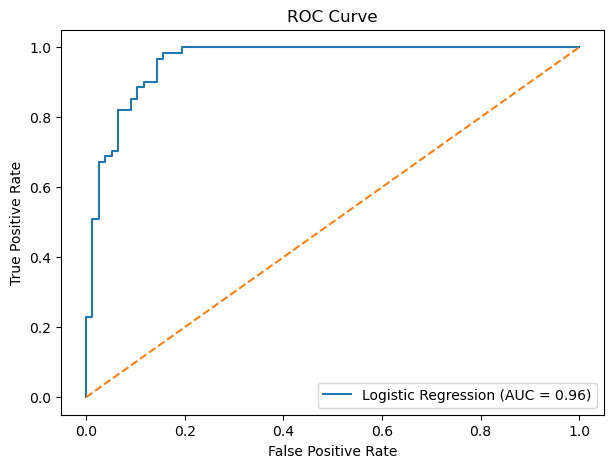

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Step 21 — Save the Best Model

In [35]:
import joblib

# Save the trained model
joblib.dump(logistic_model, "credit_card_approval_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [36]:
import os

print(os.path.exists("credit_card_approval_model.pkl"))

True


### Step 22A — Test with one existing test sample

In [37]:
# Select one applicant from the test dataset
sample_applicant = X_test.iloc[[0]]

# Predict class
prediction = logistic_model.predict(sample_applicant)[0]

# Predict probability
probability = logistic_model.predict_proba(sample_applicant)[0]

print("Prediction:", prediction)
print("Probability of Class 0:", probability[0])
print("Probability of Class 1:", probability[1])

Prediction: 1
Probability of Class 0: 0.4745668750185349
Probability of Class 1: 0.5254331249814651


### Step 22B — Human-readable result

In [38]:
if prediction == 1:
    print("Result: Class 1 (+)")
else:
    print("Result: Class 0 (-)")

Result: Class 1 (+)


### Step 23 — Create a Reusable Prediction Function

In [39]:
def predict_credit_approval(applicant_data):
    prediction = logistic_model.predict(applicant_data)[0]
    probability = logistic_model.predict_proba(applicant_data)[0]

    if prediction == 1:
        result = "Class 1 (+)"
    else:
        result = "Class 0 (-)"

    return result, probability[1]

In [40]:
result, probability = predict_credit_approval(sample_applicant)

print("Prediction:", result)
print("Class 1 Probability:", f"{probability * 100:.2f}%")

Prediction: Class 1 (+)
Class 1 Probability: 52.54%
